In [1]:
import pandas as pd
import numpy as np

In [2]:
sales = pd.read_csv("../scripts/sales.csv")

products = pd.read_csv("../scripts/products.csv")

stores = pd.read_csv("../scripts/stores.csv")

inventory = pd.read_csv("../scripts/inventory.csv")

suppliers = pd.read_csv("../scripts/suppliers.csv")

holidays = pd.read_csv("../scripts/holidays.csv")

In [3]:
datasets = {
    "Sales": sales,
    "Products": products,
    "Stores": stores,
    "Inventory": inventory,
    "Suppliers": suppliers,
    "Holidays": holidays
}

for name, df in datasets.items():

    print("="*50)

    print(name)

    print("="*50)

    print(df.head())

    print()

Sales
    sale_date  store_id  product_id  quantity_sold  discount_percentage  \
0  2025-01-01         1           1             41                    0   
1  2025-01-01         1           2             33                    0   
2  2025-01-01         1           3             34                   15   
3  2025-01-01         1           4             30                   10   
4  2025-01-01         1           5             15                    0   

    revenue  
0  17652.55  
1   7842.12  
2   5506.32  
3   8434.26  
4   1476.45  

Products
   product_id product_name category   price  shelf_life_days  supplier_id  \
0           1       Milk 1    Dairy  430.55               54            7   
1           2     Butter 2    Dairy  237.64              189            3   
2           3     Butter 3    Dairy  190.53              346            5   
3           4       Milk 4    Dairy  312.38               90            9   
4           5     Cheese 5    Dairy   98.43              197    

In [4]:
for name, df in datasets.items():

    print("="*50)

    print(name)

    print("="*50)

    print(df.shape)

    print()

Sales
(730000, 6)

Products
(100, 7)

Stores
(20, 7)

Inventory
(2000, 7)

Suppliers
(10, 5)

Holidays
(9, 2)



In [5]:
for name, df in datasets.items():

    print("="*50)

    print(name)

    print("="*50)

    print(df.info())

    print()

Sales
<class 'pandas.DataFrame'>
RangeIndex: 730000 entries, 0 to 729999
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   sale_date            730000 non-null  str    
 1   store_id             730000 non-null  int64  
 2   product_id           730000 non-null  int64  
 3   quantity_sold        730000 non-null  int64  
 4   discount_percentage  730000 non-null  int64  
 5   revenue              730000 non-null  float64
dtypes: float64(1), int64(4), str(1)
memory usage: 33.4 MB
None

Products
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   product_id       100 non-null    int64  
 1   product_name     100 non-null    str    
 2   category         100 non-null    str    
 3   price            100 non-null    float64
 4   shelf_life_days  100 non-null    int64  

In [6]:
for name, df in datasets.items():

    print("="*50)

    print(name)

    print("="*50)

    print(df.isnull().sum())

    print()

Sales
sale_date              0
store_id               0
product_id             0
quantity_sold          0
discount_percentage    0
revenue                0
dtype: int64

Products
product_id         0
product_name       0
category           0
price              0
shelf_life_days    0
supplier_id        0
is_active          0
dtype: int64

Stores
store_id        0
store_name      0
city            0
state           0
store_type      0
opening_date    0
is_active       0
dtype: int64

Inventory
inventory_id     0
store_id         0
product_id       0
current_stock    0
minimum_stock    0
maximum_stock    0
last_updated     0
dtype: int64

Suppliers
supplier_id       0
supplier_name     0
city              0
country           0
lead_time_days    0
dtype: int64

Holidays
date            0
holiday_name    0
dtype: int64



In [7]:
for name, df in datasets.items():

    print("="*50)

    print(name)

    print("="*50)

    print(df.duplicated().sum())

    print()

Sales
0

Products
0

Stores
0

Inventory
0

Suppliers
0

Holidays
0



In [8]:
sales["sale_date"] = pd.to_datetime(
    sales["sale_date"]
)

In [9]:
sales.describe()

,sale_date,store_id,product_id,quantity_sold,discount_percentage,revenue
count,730000,730000.000000,730000.00000,730000.000000,730000.000000,730000.000000
mean,2025-07-01 23:59:59.999999,10.500000,50.50000,24.676384,7.138390,5881.963771
min,2025-01-01 00:00:00,1.000000,1.00000,1.000000,0.000000,17.250000
25%,2025-04-02 00:00:00,5.750000,25.75000,16.000000,0.000000,2281.850000
50%,2025-07-02 00:00:00,10.500000,50.50000,24.000000,5.000000,4817.550000
75%,2025-10-01 00:00:00,15.250000,75.25000,33.000000,15.000000,8611.060000
max,2025-12-31 00:00:00,20.000000,100.00000,84.000000,20.000000,37184.510000
std,NaN,5.766285,28.86609,10.903210,7.491548,4403.694024


In [10]:
Q1 = sales["quantity_sold"].quantile(0.25)

Q3 = sales["quantity_sold"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

outliers = sales[
    (sales["quantity_sold"] < lower)
    |
    (sales["quantity_sold"] > upper)
]

print(outliers.shape)

outliers.head()

(1413, 6)


,sale_date,store_id,product_id,quantity_sold,discount_percentage,revenue
21620,2025-01-11,17,21,60,5,17801.67
121720,2025-03-02,18,21,59,0,18426.29
145161,2025-03-14,12,62,59,20,15017.15
180368,2025-04-01,4,69,60,0,26823.60
180529,2025-04-01,6,30,59,15,10607.73


array([[<Axes: title={'center': 'quantity_sold'}>]], dtype=object)

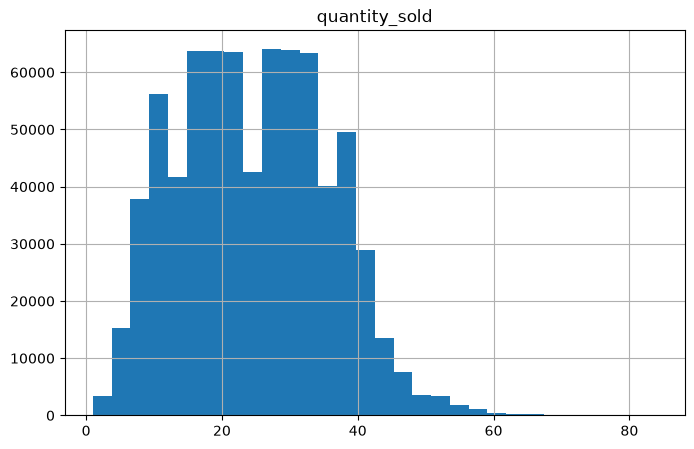

In [11]:
sales.hist(
    column="quantity_sold",
    bins=30,
    figsize=(8,5)
)

array([[<Axes: title={'center': 'revenue'}>]], dtype=object)

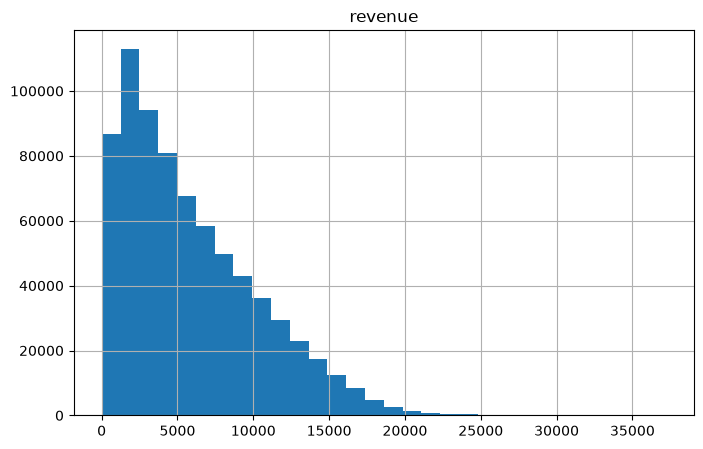

In [12]:
sales.hist(
    column="revenue",
    bins=30,
    figsize=(8,5)
)

In [13]:
print("Cleaning Completed")

Cleaning Completed
